# Fase 2b — Sarta combinada (multi-tapered)

Extension del solver de onda para sartas con multiples tramos de distinto diametro/material.

**Condicion de interfaz**: continuidad de desplazamiento y fuerza axial.

$$u_k(x_{int}) = u_{k+1}(x_{int}) \quad ; \quad E_k A_k \frac{\partial u_k}{\partial x} = E_{k+1} A_{k+1} \frac{\partial u_{k+1}}{\partial x}$$

**Caso de prueba**: 7/8" x 550m + 3/4" x 550m (Seccion 6.4)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator.params import (
    rod_L, rod_E, rod_rho, rod_A, rod_a, rod_c, rod_tapered,
    N_nodes, dt, g, W_rod
)
from aib_simulator.rod_string import WaveSolver, TaperedWaveSolver

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("Sarta combinada (2 tramos):")
for i, sec in enumerate(rod_tapered):
    a_k = np.sqrt(sec['E'] / sec['rho'])
    print(f"  Tramo {i+1} ({sec['name']}): L={sec['L']}m, d={sec['d']*1000:.2f}mm, "
          f"A={sec['A']*1e6:.0f}mm2, a={a_k:.0f}m/s")

Sarta combinada (2 tramos):
  Tramo 1 (Superior 7/8"): L=550.0m, d=22.23mm, A=388mm2, a=5048m/s
  Tramo 2 (Inferior 3/4"): L=550.0m, d=19.05mm, A=285mm2, a=5048m/s


## Validacion 1: Dos tramos iguales = sarta uniforme

Si ambos tramos tienen las mismas propiedades (3/4" x 550m + 3/4" x 550m), el resultado debe coincidir con el solver uniforme de 1100m.

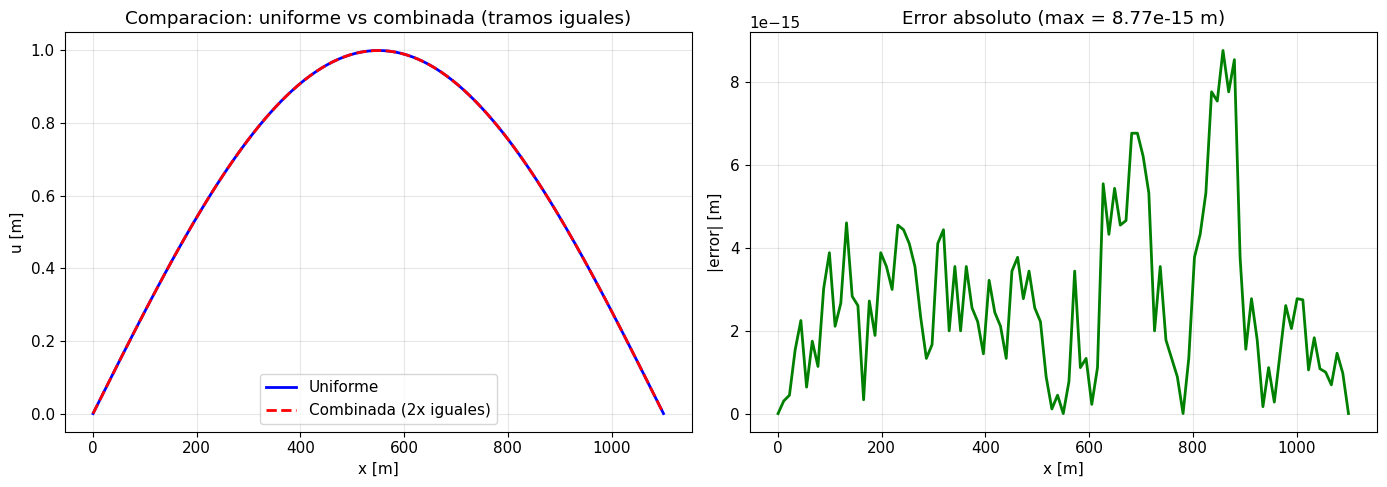

Error maximo: 8.77e-15 m
VAL 1: PASS


In [2]:
# Validacion 1: dos tramos iguales 3/4" deben coincidir con sarta uniforme
n_per_section = 50  # 50 nodos por tramo = 100 total

# Sarta uniforme de referencia
solver_uni = WaveSolver(N=100, L=rod_L, E=rod_E, rho=rod_rho, A_r=rod_A, c_damp=0.0, dt=dt)
x_uni = solver_uni.x
u0_uni = np.sin(np.pi * x_uni / rod_L)
solver_uni.initialize(u0_uni)

# Sarta combinada: dos tramos identicos
sections_equal = [
    {'L': 550.0, 'E': rod_E, 'rho': rod_rho, 'A': rod_A, 'n_nodes': n_per_section},
    {'L': 550.0, 'E': rod_E, 'rho': rod_rho, 'A': rod_A, 'n_nodes': n_per_section},
]
solver_tap = TaperedWaveSolver(sections=sections_equal, c_damp=0.0, dt=dt)
x_tap = solver_tap.x
u0_tap = np.sin(np.pi * x_tap / rod_L)
solver_tap.initialize(u0_tap)

# Simular 5 periodos
T_wave = 2 * rod_L / rod_a
n_steps = int(5 * T_wave / dt)

for step in range(n_steps):
    solver_uni.step(u_top=0.0, F_bottom=0.0)
    solver_uni.u_curr[100] = 0.0  # Dirichlet en L
    
    solver_tap.step(u_top=0.0, F_bottom=0.0)
    solver_tap.u_curr[-1] = 0.0

# Comparar
# Las mallas pueden tener distinto numero de nodos, interpolar
u_uni_final = solver_uni.u_curr
u_tap_final = solver_tap.u_curr

# Interpolar tapered a la malla uniforme
u_tap_interp = np.interp(x_uni, x_tap, u_tap_final)
error_max = np.max(np.abs(u_uni_final - u_tap_interp))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(x_uni, u_uni_final, 'b-', linewidth=2, label='Uniforme')
ax1.plot(x_tap, u_tap_final, 'r--', linewidth=2, label='Combinada (2x iguales)')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('u [m]')
ax1.set_title('Comparacion: uniforme vs combinada (tramos iguales)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x_uni, np.abs(u_uni_final - u_tap_interp), 'g-', linewidth=2)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('|error| [m]')
ax2.set_title(f'Error absoluto (max = {error_max:.2e} m)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error maximo: {error_max:.2e} m")
print(f"VAL 1: {'PASS' if error_max < 1e-6 else 'FAIL'}")

## Validacion 2: Sarta real 7/8" x 550m + 3/4" x 550m

Observar reflexion/transmision parcial en la interfaz entre tramos de distinta seccion.

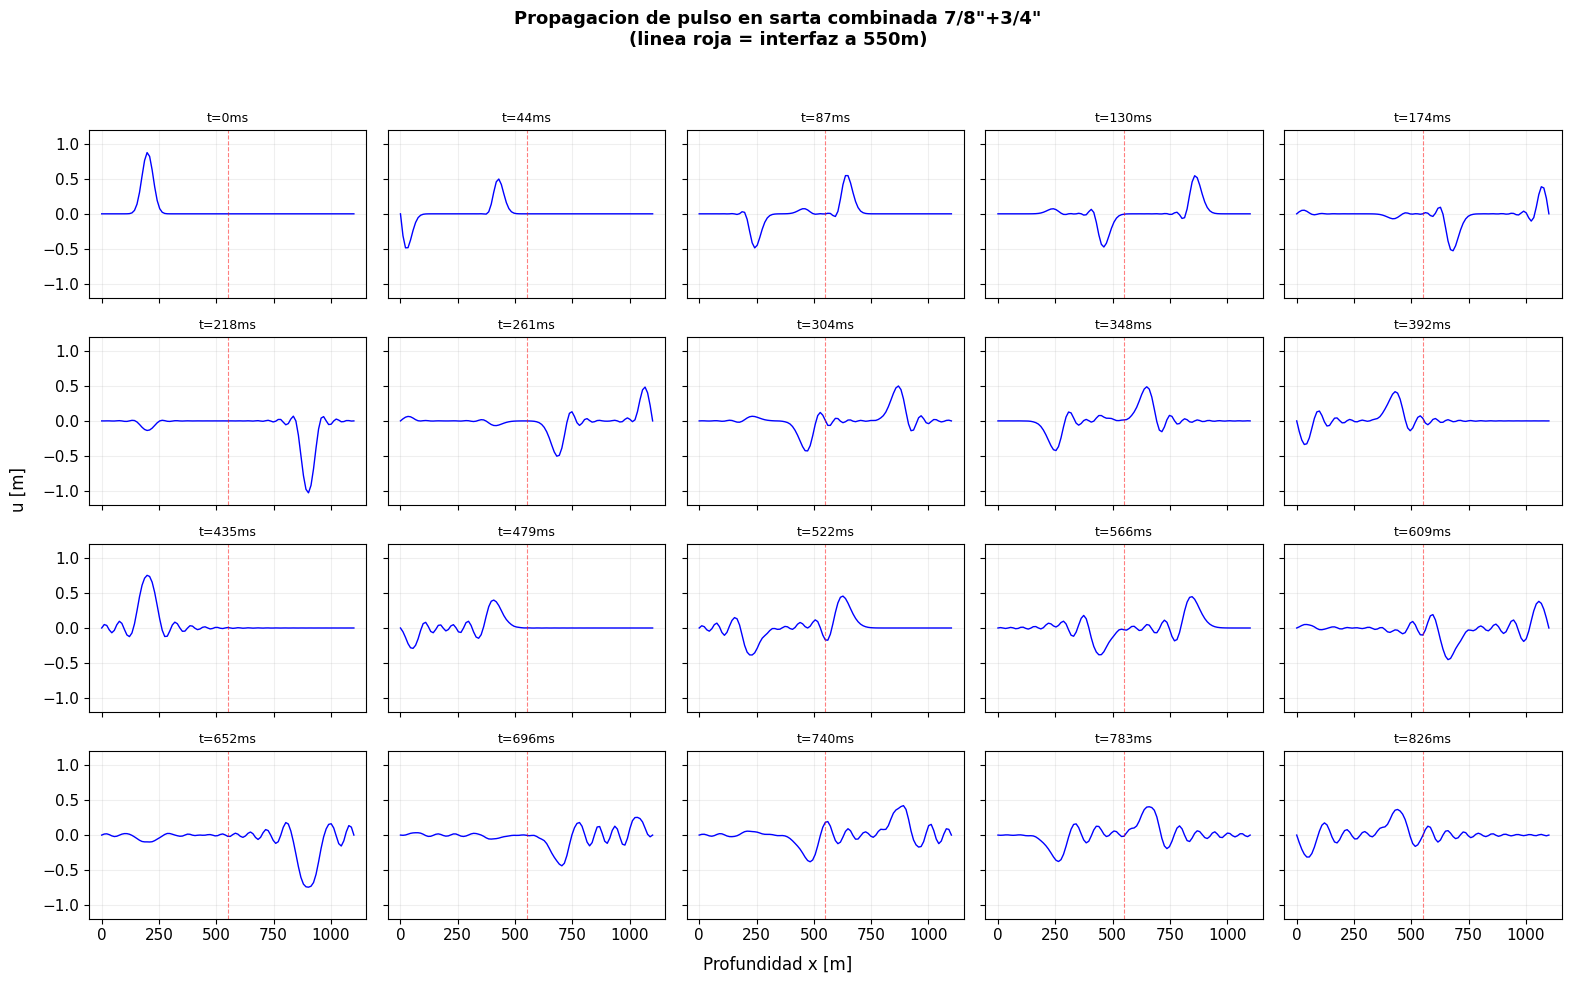


Coeficiente de reflexion teorico (impedancias): R = 0.1530
  A_78 = 388 mm2, A_34 = 285 mm2
  Se espera reflexion parcial del 15.3% de la amplitud
VAL 2: Verificar visualmente la reflexion parcial en la interfaz


In [3]:
# Validacion 2: sarta real 7/8" + 3/4"
A_78 = rod_tapered[0]['A']  # 388 mm2
A_34 = rod_tapered[1]['A']  # 285 mm2

sections_real = [
    {'L': 550.0, 'E': rod_E, 'rho': rod_rho, 'A': A_78, 'n_nodes': 50},
    {'L': 550.0, 'E': rod_E, 'rho': rod_rho, 'A': A_34, 'n_nodes': 50},
]
solver_real = TaperedWaveSolver(sections=sections_real, c_damp=0.0, dt=dt)
x_real = solver_real.x
L_total = 1100.0

# CI: pulso gaussiano centrado en el primer tramo
x_center = 200.0
sigma = 30.0
u0_pulse = np.exp(-((x_real - x_center) / sigma)**2)
solver_real.initialize(u0_pulse)

# Simular y capturar snapshots
T_wave = 2 * L_total / rod_a
n_steps = int(2 * T_wave / dt)
save_every = n_steps // 20
snapshots = []
snap_times = []

for step in range(n_steps):
    solver_real.step(u_top=0.0, F_bottom=0.0)
    solver_real.u_curr[-1] = 0.0
    if step % save_every == 0:
        snapshots.append(solver_real.u_curr.copy())
        snap_times.append(step * dt)

# Graficar propagacion con interfaz
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flat):
    if idx < len(snapshots):
        ax.plot(x_real, snapshots[idx], 'b-', linewidth=1)
        ax.axvline(550, color='r', linestyle='--', alpha=0.5, linewidth=0.8)
        ax.set_title(f't={snap_times[idx]*1000:.0f}ms', fontsize=9)
        ax.set_ylim(-1.2, 1.2)
        ax.grid(True, alpha=0.2)

fig.text(0.5, 0.02, 'Profundidad x [m]', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'u [m]', va='center', rotation=90, fontsize=12)
plt.suptitle('Propagacion de pulso en sarta combinada 7/8\"+3/4\"\n'
             '(linea roja = interfaz a 550m)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

# Coeficiente de reflexion teorico
R_coeff = (A_78 - A_34) / (A_78 + A_34)
print(f"\nCoeficiente de reflexion teorico (impedancias): R = {R_coeff:.4f}")
print(f"  A_78 = {A_78*1e6:.0f} mm2, A_34 = {A_34*1e6:.0f} mm2")
print(f"  Se espera reflexion parcial del {abs(R_coeff)*100:.1f}% de la amplitud")
print(f"VAL 2: Verificar visualmente la reflexion parcial en la interfaz")